# MSI 5001 Introduction to AI: Concepts, Applications, and Evaluation (Capstone Project)

## Deep Learning Modelling

- **Group:** 26
- **Members:** Alkaff, Dev, Kee Fong


## Overview

- 2D CNN (3 Blocks) → Spectrograph
- 2D CNN (4 Blocks) → Spectrograph
- CRNN → Spectrograph


## Import Statements and Setup


In [1]:
# Import Statements
# -----------------

import os
import random
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, log_loss
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras import optimizers, callbacks
from tensorflow.keras.models import load_model


In [2]:
# Check GPU
# ---------

from tensorflow.python.client import device_lib

# Display all logical devices
for device in device_lib.list_local_devices():
    if device.device_type == 'GPU':
        print(f"✅ GPU Detected: {device.name} | {device.physical_device_desc}")


✅ GPU Detected: /device:GPU:0 | device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [3]:
# SPEED SWITCHES
# --------------

from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")  # big speedup on 30xx GPUs
#tf.config.optimizer.set_jit(True)   

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6


In [4]:
# Global Config
# -------------

BASE_DIR = Path("D:\\MSI5001 Datasets\\Urban Sound")
RAW_TRAIN_ROOT = BASE_DIR / "raw" / "Train"
RAW_TEST_ROOT = BASE_DIR / "raw" / "Test"

MFCC_TRAIN_ROOT = BASE_DIR / "mfcc" / "Train"
MFCC_TEST_ROOT = BASE_DIR / "mfcc" / "Test"
SPECTRO_TRAIN_ROOT = BASE_DIR / "mel_spectro" / "Train"
SPECTRO_TEST_ROOT = BASE_DIR / "mel_spectro" / "Test"
WAV24_TRAIN_ROOT = BASE_DIR / "wave_24k" / "Train"
WAV24_TEST_ROOT = BASE_DIR / "wave_24k" / "Test"

MFCC_FEATS_TRAIN = BASE_DIR / "mfcc_features_train_clean.csv"    # columns: sample (file), F0..F1199, label
MFCC_FEATS_TEST = BASE_DIR / "mfcc_features_test.csv"      # columns: sample (file), F0..F1199, label
PCA50_TRAIN = BASE_DIR / "mfcc_pca50_train_clean.csv"    # columns: sample (file),label, PC1..PC50
PCA50_TEST = BASE_DIR / "mfcc_pca50_test.csv"      # columns: sample (file),label, PC1..PC50

SPLITS = ["Train", "Test"]


In [5]:
# Process Config
# --------------

RANDOM_STATE = 42  # keep consistent with training cell

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

IMG_HEIGHT, IMG_WIDTH = 128, 186
CHANNELS = 1  # grayscale
N_CLASSES = 10

BATCH_SIZE = 32
VAL_SPLIT = 0.2
N_EPOCH = 100


In [25]:
# Helper Functions
# ----------------

def plot_loss_acc(df, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Accuracy plot
    axes[0].plot(df['accuracy'], label='Train Accuracy')
    axes[0].plot(df['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title(f'{title} Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss plot
    axes[1].plot(df['loss'], label='Train Loss')
    axes[1].plot(df['val_loss'], label='Validation Loss')
    axes[1].set_title(f'{title} Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()


def calculate_macro_metrics(y, y_hat, title):
    acc = accuracy_score(y, y_hat)
    prec = precision_score(y, y_hat, average="macro", zero_division=0)
    rec  = recall_score(y, y_hat, average="macro", zero_division=0)
    f1   = f1_score(y, y_hat, average="macro", zero_division=0)
    return [title, float(acc), float(prec), float(rec), float(f1)]


def print_classification_report(y, y_hat, title):
    print(f"\n=== Classification Report: {title} ===")
    print(classification_report(y, y_hat, digits=4, zero_division=0))


def plot_confusion_mat(y, y_hat, title, filename):
    cm = confusion_matrix(y, y_hat)

    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=[str(i) for i in range(cm.shape[1])],
        yticklabels=[str(i) for i in range(cm.shape[0])]
    )
    
    plt.title(f"Confusion Matrix — {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    
    plt.savefig(filename)
    plt.show()




## Load Dataset

- Load the png files
- Normalise: `0-255` → `0-1` by $\div 255$


In [7]:
# Class Mapping
# -------------

classes = sorted([d.name for d in SPECTRO_TRAIN_ROOT.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Class mapping:", class_to_idx)
print("Reverse Class mapping:", idx_to_class)

Class mapping: {'air_conditioner': 0, 'car_horn': 1, 'children_playing': 2, 'dog_bark': 3, 'drilling': 4, 'engine_idling': 5, 'gun_shot': 6, 'jackhammer': 7, 'siren': 8, 'street_music': 9}
Reverse Class mapping: {0: 'air_conditioner', 1: 'car_horn', 2: 'children_playing', 3: 'dog_bark', 4: 'drilling', 5: 'engine_idling', 6: 'gun_shot', 7: 'jackhammer', 8: 'siren', 9: 'street_music'}


In [8]:
# Load Dataset
# ------------

X_list, y_list = [], []

for class_name, idx in class_to_idx.items():
    class_folder = SPECTRO_TRAIN_ROOT / class_name
    pngs = sorted(class_folder.glob("*.png"))
    for p in pngs:
        # Load grayscale; target_size guards against accidental size drift
        img = load_img(p, color_mode="grayscale", target_size=(IMG_HEIGHT, IMG_WIDTH))
        arr = img_to_array(img)  # shape: (H, W, 1), dtype=float32 in [0,255]
        X_list.append(arr)
        y_list.append(idx)

X = np.stack(X_list, axis=0)  # (N, 128, 186, 1)
y = np.array(y_list, dtype=np.int64)

# Normalization (recommended even if loudness was normalized) ---
# PNGs load as [0,255] floats → scale to [0,1] for stable optimization.

X = X / 255.0
X = X.astype("float32")

print(X.shape)
print(y.shape)


(1721, 128, 186, 1)
(1721,)


In [9]:
# Shuffle Dataset
# ---------------

# This step is required because validation split takes the last 20% as validation

rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(len(X))
X = X[perm]
y = y[perm]

print(y)

[7 5 4 ... 9 5 9]


## Calculate Class Weights for Imbalanced Dataset



In [10]:
# Calculate Class Weights
# -----------------------

print(f"[INFO] X shape: {X.shape}, y shape: {y.shape}, classes: {len(class_to_idx)}")
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y
)

class_weights = dict(enumerate(class_weights_array))

print("[INFO] Computed class weights:")
for cls_idx, w in class_weights.items():
    print(f"  Class {cls_idx} ({list(class_to_idx.keys())[cls_idx]}): {w:.3f}")


[INFO] X shape: (1721, 128, 186, 1), y shape: (1721,), classes: 10
[INFO] Computed class weights:
  Class 0 (air_conditioner): 0.878
  Class 1 (car_horn): 2.206
  Class 2 (children_playing): 0.883
  Class 3 (dog_bark): 0.883
  Class 4 (drilling): 0.874
  Class 5 (engine_idling): 0.906
  Class 6 (gun_shot): 2.569
  Class 7 (jackhammer): 0.729
  Class 8 (siren): 1.001
  Class 9 (street_music): 0.883


## CNN Architecture Summary

**Input:**

- 4-second log-mel spectrograms, shaped `(128, 186, 1)` (freq × time × channel).
- All clips standardized: long → cropped, short → repeat-filled.

**Conv Blocks:**

- Each block → `Conv2D(3×3, same, no bias) → BatchNorm → ReLU → MaxPool(2×2)`.
- Filters increase by depth: `[32, 64, 128]` (3-block) or `[32, 64, 128, 256]` (4-block).

**Pooling:**

- Every block halves both frequency and time resolution (2×2).
- Promotes invariance to small shifts in pitch and event timing.

**Global Average Pooling:**

- Aggregates features across the whole spectrogram → clip-level embedding.
- Focuses on *what* sound patterns exist, not *where* they occur.

**Regularization:**

- `Dropout(0.5)` after global pooling to curb overfitting.

**Output:**

- Dense layer with `softmax` → 10-way class probabilities.


### Explanation

- **Convolutional Front-End:**
  - Standard for spectrogram-based audio classification.
  - Captures joint time–frequency textures (e.g., hums, sirens, drilling).
- **Progressive Depth:**
  - Early layers learn local textures (harmonics, bursts).
  - Deeper layers capture higher-level acoustic structures.
- **Pooling Strategy:**
  - Reduces sensitivity to timing and pitch variation.
  - Enables smaller spatial representations → faster training, less memory.
- **Global Aggregation:**
  - Ideal since dataset has clip-level (not frame-level) labels.
- **Dropout:**
  - Effective against overfitting given limited dataset size.
- **Model Variants:**
  - **3-Block CNN:** balanced depth, faster training, good regularization.
  - **4-Block CNN:** deeper representation, slightly higher capacity but heavier compute.


In [66]:
# CNN Model Architecture
# ----------------------

def build_cnn_model(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
    num_classes=N_CLASSES,
    filters=[32, 64, 128, 256],
    dropout_rate=0.5,
):
    """
    Build a CNN for environmental sound classification.

    input_shape: (freq_bins, time_steps, 1)
    num_classes: number of output classes
    filters: list of channel sizes for each Conv block
             e.g. [32, 64, 128, 256]
    dropout_rate: dropout after global pooling
    """

    inputs = layers.Input(shape=input_shape)
    x = inputs

    for i, f in enumerate(filters):
        x = layers.Conv2D(
            filters=f,
            kernel_size=(3, 3),
            padding="same",
            use_bias=False,
            name=f"conv_block{i+1}_conv"
        )(x)
        x = layers.BatchNormalization(name=f"conv_block{i+1}_bn")(x)
        x = layers.ReLU(name=f"conv_block{i+1}_relu")(x)
        x = layers.MaxPooling2D(pool_size=(2, 2), name=f"conv_block{i+1}_pool")(x)

    # Global average pooling -> clip-level embedding
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)

    # Regularization to reduce overfitting
    x = layers.Dropout(dropout_rate, name="dropout")(x)

    # Final classifier
    outputs = layers.Dense(num_classes, activation="softmax", name="classifier")(x)

    model = models.Model(inputs, outputs, name="cnn_urban")
    return model


In [69]:
# Callbacks
# ---------

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

ckpt = callbacks.ModelCheckpoint(
    filepath=BASE_DIR / "best_cnn_3b.keras",
    monitor="val_accuracy",
    save_best_only=True
)


In [68]:
# Build CNN Model (and Compile) - 3 BLOCKS
# ----------------------------------------

model = build_cnn_model(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
    num_classes=N_CLASSES,
    filters=[32, 64, 128],
    dropout_rate=0.5,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",  # integer class labels 0..9
    metrics=["accuracy"]
)

model.summary()


Model: "cnn_urban"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 128, 186, 1)]     0         
                                                                 
 conv_block1_conv (Conv2D)   (None, 128, 186, 32)      288       
                                                                 
 conv_block1_bn (BatchNormal  (None, 128, 186, 32)     128       
 ization)                                                        
                                                                 
 conv_block1_relu (ReLU)     (None, 128, 186, 32)      0         
                                                                 
 conv_block1_pool (MaxPoolin  (None, 64, 93, 32)       0         
 g2D)                                                            
                                                                 
 conv_block2_conv (Conv2D)   (None, 64, 93, 64)        18

### TRAIN CNN

- This step takes almost 20 mins


In [70]:
# !!! TRAIN MODEL !!!
# -------------------

history = model.fit(
    x=X, y=y,
    epochs=N_EPOCH,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    shuffle=True,
    callbacks=[early_stop, reduce_lr, ckpt],
    #class_weight=class_weights,
    verbose=1
)

Epoch 1/100
43/43 [==============================] - 15s 215ms/step - loss: 2.1083 - accuracy: 0.2449 - val_loss: 2.4685 - val_accuracy: 0.1826 - lr: 0.0100
Epoch 2/100
43/43 [==============================] - 9s 206ms/step - loss: 1.7180 - accuracy: 0.3939 - val_loss: 2.3830 - val_accuracy: 0.1768 - lr: 0.0100
Epoch 3/100
43/43 [==============================] - 9s 206ms/step - loss: 1.5359 - accuracy: 0.4688 - val_loss: 2.6675 - val_accuracy: 0.1217 - lr: 0.0100
Epoch 4/100
43/43 [==============================] - 9s 206ms/step - loss: 1.4600 - accuracy: 0.4826 - val_loss: 3.0002 - val_accuracy: 0.1130 - lr: 0.0100
Epoch 5/100
43/43 [==============================] - 9s 206ms/step - loss: 1.3475 - accuracy: 0.5400 - val_loss: 3.2401 - val_accuracy: 0.1043 - lr: 0.0100
Epoch 6/100
43/43 [==============================] - 9s 206ms/step - loss: 1.2684 - accuracy: 0.5654 - val_loss: 3.8020 - val_accuracy: 0.1043 - lr: 0.0100
Epoch 7/100
43/43 [==============================] - 9s 206ms/s

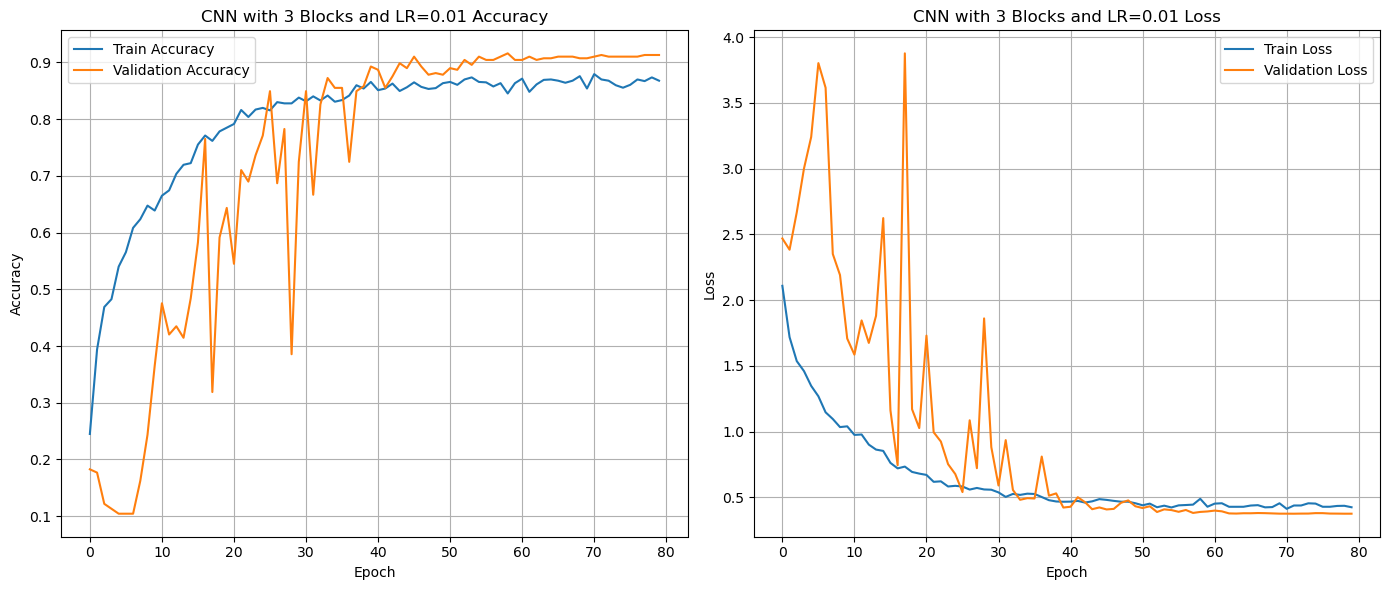

In [71]:
# Plot Accuracy and Loss
# ----------------------

plot_loss_acc(history.history, "CNN with 3 Blocks and LR=0.01", BASE_DIR / "04b_cnn_3b_lr2_plot.png")


### Observations: 

- **Early training jitter** was observed (first ~40 epochs), attributable to high initial LR, small validation set variance and BatchNorm warm-up
- After LR reductions, **both loss and accuracy stabilized** and **validation outperformed training** → consistent with dropout/BN behavior and good generalization
- The model reaches a **stable plateau**, performance gains after ~45–50 epochs are marginal → earlier stopping would reduce compute without hurting accuracy
- Final curves (val loss < train loss .and val acc > train acc) **do not indicate leakage**
    - Expected under dropout/BN
    - Indicate **robust generalization**


In [72]:
# Callbacks - Modification
# ------------------------

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5  # Changed from original 1e-6
)

ckpt = callbacks.ModelCheckpoint(
    filepath=BASE_DIR / "best_cnn_4b.keras",
    monitor="val_accuracy",
    save_best_only=True
)


In [73]:
# Build CNN Model (and Compile) - back to 4 BLOCKS
# ------------------------------------------------

model = build_cnn_model(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
    num_classes=N_CLASSES,
    filters=[32, 64, 128, 256],
    dropout_rate=0.5,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",  # integer class labels 0..9
    metrics=["accuracy"]
)

model.summary()

Model: "cnn_urban"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 128, 186, 1)]     0         
                                                                 
 conv_block1_conv (Conv2D)   (None, 128, 186, 32)      288       
                                                                 
 conv_block1_bn (BatchNormal  (None, 128, 186, 32)     128       
 ization)                                                        
                                                                 
 conv_block1_relu (ReLU)     (None, 128, 186, 32)      0         
                                                                 
 conv_block1_pool (MaxPoolin  (None, 64, 93, 32)       0         
 g2D)                                                            
                                                                 
 conv_block2_conv (Conv2D)   (None, 64, 93, 64)        18

### TRAIN CNN

- This step takes almost 20 mins


In [74]:
# !!! TRAIN MODEL !!!
# -------------------

history = model.fit(
    x=X, y=y,
    epochs=N_EPOCH,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    shuffle=True,
    callbacks=[early_stop, reduce_lr, ckpt],
    #class_weight=class_weights,
    verbose=1
)

Epoch 1/100
43/43 [==============================] - 13s 234ms/step - loss: 2.0195 - accuracy: 0.3096 - val_loss: 9.0210 - val_accuracy: 0.1275 - lr: 0.0100
Epoch 2/100
43/43 [==============================] - 10s 229ms/step - loss: 1.5118 - accuracy: 0.4731 - val_loss: 2.9508 - val_accuracy: 0.1014 - lr: 0.0100
Epoch 3/100
43/43 [==============================] - 10s 228ms/step - loss: 1.2547 - accuracy: 0.5654 - val_loss: 3.8531 - val_accuracy: 0.1043 - lr: 0.0100
Epoch 4/100
43/43 [==============================] - 10s 229ms/step - loss: 1.2149 - accuracy: 0.5850 - val_loss: 3.0558 - val_accuracy: 0.1391 - lr: 0.0100
Epoch 5/100
43/43 [==============================] - 10s 229ms/step - loss: 1.0520 - accuracy: 0.6504 - val_loss: 2.3219 - val_accuracy: 0.2145 - lr: 0.0100
Epoch 6/100
43/43 [==============================] - 10s 228ms/step - loss: 0.9420 - accuracy: 0.6890 - val_loss: 3.5445 - val_accuracy: 0.1507 - lr: 0.0100
Epoch 7/100
43/43 [==============================] - 10s 2

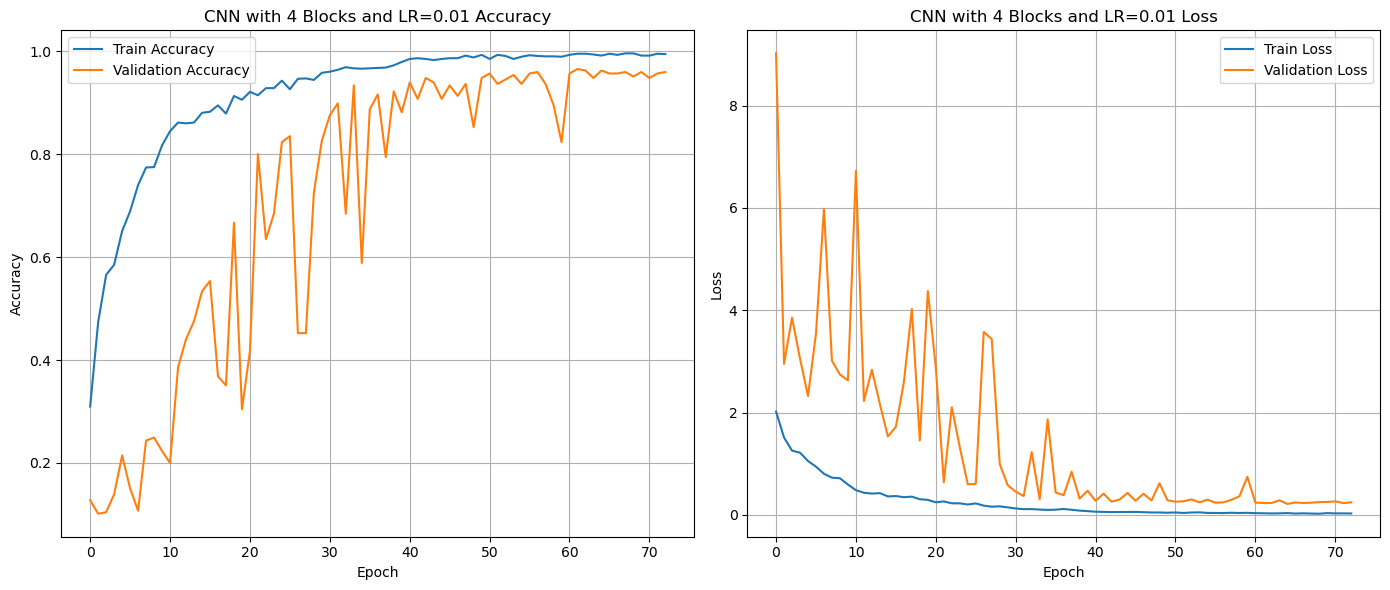

In [75]:
# Plot Accuracy and Loss
# ----------------------

plot_loss_acc(history.history, "CNN with 4 Blocks and LR=0.01", BASE_DIR / "04c_cnn_4b_lr2_plot.png")


### Observations: 

- The 4-block CNN exhibits **slightly higher capacity** and **performance** but at the cost of **greater training instability** and **mild overfitting**
- With modest tuning (lower initial LR, stronger dropout, L2, label smoothing, and early stopping), it can be stabilized.
- For practical purposes, the **3-block CNN** remains the **cleaner and more stable** baseline for this dataset.


## CRNN Architecture Summary

- **Input / Shape**
  - Log-mel spectrograms shaped (128, 186, 1) = (freq, time, channel)
- **CNN front-end (feature extractor) — 3 blocks**
  - **CNN Block:** `Conv2D(3×3, filters=[32,64,128], same, no bias) → BN → ReLU → MaxPool`
  - **Pooling:**
    - Blocks 1–2: `MaxPool2D(2,1)` (downsample **freq only**, keep time)
    - Block 3 (last): `MaxPool2D(2,3)` (downsample **freq and time** lightly)
  - **Per-block dropout:** `[0.25, 0.25, 0.30]`
  - **After all CNN blocks:** extra **Dropout(0.10)**
- **Time reformatting for RNN**
  - `Permute` → move time to axis-1
  - `Reshape` → (time_steps, features) by flattening `(freq'×channels)`
- **Per-time-step projection**
  - `Dense(128, ReLU)` on the last dim → compact feature vector per frame
  - `Dropout(0.10)` after projection
- **RNN back-end**
  - Single GRU(128, return_sequences=False, dropout=0.30, recurrent_dropout=0.0)
  - No BiGRU, chosen for speed/VRAM
- **Classifier head**
  - `Dense(128, ReLU) → Dropout(0.50) → Dense(num_classes, Softmax)`


### Explanation

- **Single-conv blocks (not double)**
  - Keeps params & VRAM low
  - Faster training
  - Reduces overfitting risk on this dataset
- **Pooling strategy**
  - Early `Pool(2,1)` preserves the **time axis** so RNN still sees sequence dynamics
  - Final `Pool(2,3)` trims sequence length modestly → cheaper GRU while keeping temporal context
- **Per-block CNN dropouts + small final CNN dropout**
  - Regularizes **each scale** of features and the combined representation
  - Combats mild overfit seen in deeper CNNs
- **Permute + Reshape to (T, F)**
  - Converts 2D feature maps into a sequence the GRU can process (frame-wise descriptors)
- **Projection layer (Dense 128)**
  - Bottlenecks high-dim CNN features → **stabilizes** RNN training, cuts compute, improves generalization
- **GRU over (Bi)GRU**
  - GRU is lighter than LSTM/BiGRU → fits **RTX 3050 (4 GB VRAM)** comfortably
  - Quicker epochs (`19s` vs `40s`)
  - `recurrent_dropout=0.0` keeps **GPU fast path**
  - `dropout=0.30` regularizes inputs between timesteps
- **Head: Dense 128 + Dropout 0.50**
  - Adds non-linear mixing before classification
  - Strong dropout to curb final-layer overfit
- **Overall rationale**
  - **CNN** learns time–frequency patterns
  - **GRU** models temporal evolution
  - Architecture balances **capacity vs. stability**: good accuracy, tolerable compute, and reduced overfit relative to heavier CRNNs


In [50]:
# CRNN Model Architecture
# -----------------------

def build_crnn_model(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
    num_classes=N_CLASSES,
    is_double_cnn=True,                 # recommended for CRNN front-end
    filters=[32, 64, 128],
    cnn_dropouts=[0.25, 0.25, 0.30],    # one per block (len MUST match len(filters))
    final_cnn_dropout=0.10,             # small global CNN dropout after all blocks
    dense_dropout=0.50,                 # stronger head dropout
    rnn_dropout_rate=0.30,              # GRU input/forward dropout (no recurrent_dropout)
    proj_dim=256,                       # NEW: per-time-step feature bottleneck
    rnn_units=(128,),                   # NEW: BiGRU widths (first returns sequences)
):
    """
    CRNN for log-mel spectrograms:
      - CNN front-end (single or double conv blocks)
      - Time-preserving pooling (pool freq first; light time pool at the end)
      - BiGRU stack (no recurrent_dropout to keep GPU fast path)
      - Dense head

    Args:
        input_shape: (H, W, C) = (freq_bins, time_frames, channels)
        num_classes: number of output classes
        is_double_cnn: if True → [Conv→BN→ReLU]×2 per block; else single
        filters: list of conv filter sizes; length = # of CNN blocks
        cnn_dropout_rate: dropout after each CNN block
        final_cnn_dropout: dropout after all CNN blocks
        dense_dropout: dropout after dense layer
        rnn_dropout_rate: dropout inside BiGRU (input/forward dropout only)
                          (recurrent_dropout is fixed to 0.0 for GPU fast path)
    Returns:
        tf.keras.Model (uncompiled)
    """
    if len(cnn_dropouts) != len(filters):
        raise ValueError(f"`cnn_dropouts` must have length {len(filters)} (got {len(cnn_dropouts)}).")

    inp = layers.Input(shape=input_shape, name="input_spectrogram")
    x = inp

    # ----- CNN feature extractor -----
    n_blocks = len(filters)
    for i, (f, p) in enumerate(zip(filters, cnn_dropouts)):
        # first conv (always)
        x = layers.Conv2D(
            filters=f,
            kernel_size=(3, 3),
            padding="same",
            use_bias=False,
            name=f"conv_block{i+1}_a_conv"
        )(x)
        x = layers.BatchNormalization(name=f"bn{i+1}_a")(x)
        x = layers.ReLU(name=f"relu{i+1}_a")(x)

        if is_double_cnn:
            # second conv in the same block
            x = layers.Conv2D(
                filters=f,
                kernel_size=(3, 3),
                padding="same",
                use_bias=False,
                name=f"conv_block{i+1}_b_conv"
            )(x)
            x = layers.BatchNormalization(name=f"bn{i+1}_b")(x)
            x = layers.ReLU(name=f"relu{i+1}_b")(x)

        # pooling: preserve time in early blocks, lightly reduce time in the last
        if i < n_blocks - 1:
            # downsample frequency only
            x = layers.MaxPooling2D(pool_size=(2, 1), name=f"pool{i+1}_freq")(x)
        else:
            # final block: downsample both freq and time a bit
            x = layers.MaxPooling2D(pool_size=(2, 3), name=f"pool{i+1}_freq_time")(x)

        # Per-block dropout
        if p and p > 0.0:
            x = layers.Dropout(float(p), name=f"dropout_cnn_block{i+1}")(x)
    
    # Optional final CNN dropout (once after all blocks)
    if final_cnn_dropout and final_cnn_dropout > 0.0:
        x = layers.Dropout(final_cnn_dropout, name="dropout_cnn_final")(x)

    # x shape: (freq', time', channels)
    # ----- reshape to (time, features) for RNN -----
    # permute to (time', freq', channels)
    # From (B, F', T', C) to (B, T', F'*C)
    
    x = layers.Permute((2, 1, 3), name="permute_time_first")(x)
    
    # flatten freq' * channels as feature dim
    t_steps = tf.shape(x)[1]  # dynamic time dimension for clarity (not used directly in Reshape)
    f_bins  = x.shape[2]      # static freq'
    ch      = x.shape[3]      # static channels

    # Use -1 for time steps so it stays dynamic
    x = layers.Reshape((-1, f_bins * ch))(x)

    # Per-time-step projection (Dense on last dim works on 3D tensors)
    x = layers.Dense(proj_dim, activation="relu", name="time_proj")(x)
    x = layers.Dropout(0.1, name="dropout_after_proj")(x)  # small extra regularization

    # ----- BiGRU stack (no recurrent_dropout for GPU fast path) -----
    x = layers.GRU(
            rnn_units[0], 
            return_sequences=False, #True, 
            dropout=rnn_dropout_rate, 
            recurrent_dropout=0.0, 
            name="gru"
        )(x)
    """x = layers.GRU(
            rnn_units[1], 
            return_sequences=False, 
            dropout=rnn_dropout_rate, 
            recurrent_dropout=0.0, 
            name="gru2"
        )(x)"""

    # ----- Classifier head -----
    x = layers.Dense(128, activation="relu", name="dense_head")(x)
    if dense_dropout and dense_dropout > 0.0:
        x = layers.Dropout(dense_dropout, name="dropout_head")(x)
    out = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = models.Model(inputs=inp, outputs=out, name="CRNN")
    return model


In [51]:
# Callbacks - Modification
# ------------------------

ckpt = callbacks.ModelCheckpoint(
    filepath=BASE_DIR / "best_crnn.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6 
)


In [52]:
# Build CRNN Model (and Compile)
# ------------------------------

model = build_crnn_model(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
    num_classes=N_CLASSES,
    is_double_cnn=False,                 # recommended for CRNN
    filters=[32, 64, 128],
    cnn_dropouts=[0.25, 0.25, 0.30],    # REQUIRED list (must match len(filters))
    final_cnn_dropout=0.10,
    dense_dropout=0.50,
    rnn_dropout_rate=0.30,              # GRU dropout; recurrent_dropout=0.0 inside builder
    proj_dim=128,                      # NEW: per-time-step feature bottleneck
    rnn_units=(128,)
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",  # integer class labels 0..9
    metrics=["accuracy"]
)

model.summary()


Model: "CRNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_spectrogram (InputLay  [(None, 128, 186, 1)]    0         
 er)                                                             
                                                                 
 conv_block1_a_conv (Conv2D)  (None, 128, 186, 32)     288       
                                                                 
 bn1_a (BatchNormalization)  (None, 128, 186, 32)      128       
                                                                 
 relu1_a (ReLU)              (None, 128, 186, 32)      0         
                                                                 
 pool1_freq (MaxPooling2D)   (None, 64, 186, 32)       0         
                                                                 
 dropout_cnn_block1 (Dropout  (None, 64, 186, 32)      0         
 )                                                            

### TRAIN CRNN

- This step takes mins


In [53]:
# !!! TRAIN MODEL !!!
# -------------------

# Explicit train/val split + stratify
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=VAL_SPLIT, random_state=RANDOM_STATE, stratify=y
)

history = model.fit(
    #x=X, y=y,
    X_tr, y_tr,
    epochs=N_EPOCH,
    batch_size=BATCH_SIZE,
    #batch_size=32,
    #validation_split=VAL_SPLIT,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stop, reduce_lr, ckpt],
    #class_weight=class_weights,
    verbose=1
)


Epoch 1/100
43/43 [==============================] - 21s 454ms/step - loss: 2.2524 - accuracy: 0.1657 - val_loss: 2.2730 - val_accuracy: 0.1275 - lr: 5.0000e-04
Epoch 2/100
43/43 [==============================] - 19s 447ms/step - loss: 2.0229 - accuracy: 0.2645 - val_loss: 2.2607 - val_accuracy: 0.1565 - lr: 5.0000e-04
Epoch 3/100
43/43 [==============================] - 19s 446ms/step - loss: 1.8705 - accuracy: 0.3176 - val_loss: 2.2436 - val_accuracy: 0.1623 - lr: 5.0000e-04
Epoch 4/100
43/43 [==============================] - 19s 446ms/step - loss: 1.7367 - accuracy: 0.3765 - val_loss: 2.2407 - val_accuracy: 0.2232 - lr: 5.0000e-04
Epoch 5/100
43/43 [==============================] - 19s 446ms/step - loss: 1.6531 - accuracy: 0.4019 - val_loss: 2.3418 - val_accuracy: 0.2522 - lr: 5.0000e-04
Epoch 6/100
43/43 [==============================] - 19s 445ms/step - loss: 1.6128 - accuracy: 0.4273 - val_loss: 2.4978 - val_accuracy: 0.1971 - lr: 5.0000e-04
Epoch 7/100
43/43 [===============

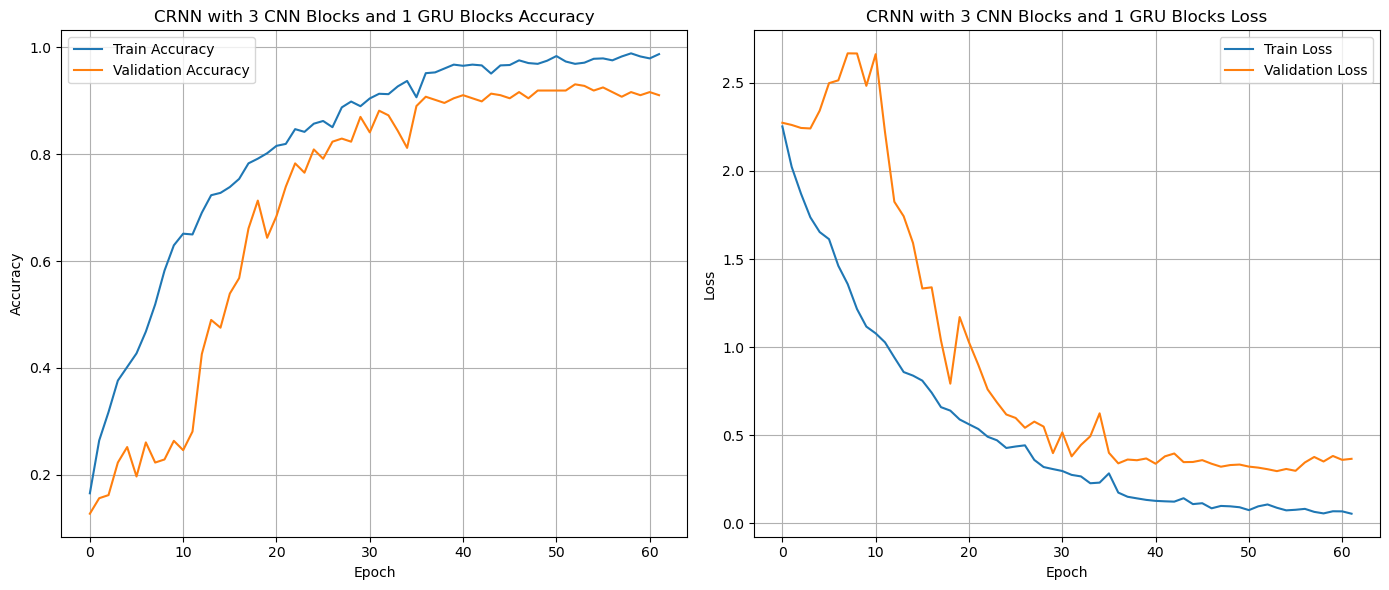

In [55]:
# Plot Accuracy and Loss
# ----------------------

plot_loss_acc(history.history, "CRNN with 3 CNN Blocks and 1 GRU Blocks", BASE_DIR / "04d_crnn_3cnn_gru128_plot.png")

### Observations

- Training slightly unstable during the first **15 epochs** due to learning rate warm-up and RNN adaptation
- **Overfitting observed:** training accuracy higher than validation accuracy, and training loss lower than validation loss
- Performance **worse than the 4-block CNN**, indicating that added temporal modeling didn’t translate into better generalization
- Validation loss **stabilizes around 30–40 epochs**, after which improvements are minimal
- Model likely **limited by dataset size** - CRNNs tend to perform better with more training data


### Possible Causes

- GRU layer adds temporal modeling capacity that may be **too large** for the dataset
- Learning rate possibly **too high** early on, leading to oscillation in loss
- Regularization strength (dropout, L2) **insufficient** to counter mild overfitting
- Small validation split → noisy metric behaviour


### Final verdict

- 3 block CNN



## Evaluate with Test Set



In [11]:
# Load TEST Dataset
# -----------------

X_list, y_list = [], []

for class_name, idx in class_to_idx.items():
    class_folder = SPECTRO_TEST_ROOT / class_name
    pngs = sorted(class_folder.glob("*.png"))
    for p in pngs:
        # Load grayscale; target_size guards against accidental size drift
        img = load_img(p, color_mode="grayscale", target_size=(IMG_HEIGHT, IMG_WIDTH))
        arr = img_to_array(img)  # shape: (H, W, 1), dtype=float32 in [0,255]
        X_list.append(arr)
        y_list.append(idx)

X_test = np.stack(X_list, axis=0)  # (N, 128, 186, 1)
y_test = np.array(y_list, dtype=np.int64)

# Normalization (recommended even if loudness was normalized) ---
# PNGs load as [0,255] floats → scale to [0,1] for stable optimization.

X_test = X_test / 255.0
X_test = X_test.astype("float32")

print(X_test.shape)
print(y_test.shape)


(837, 128, 186, 1)
(837,)


In [13]:
# Load Model + Do Predictions
# ---------------------------

cnn3 = load_model(BASE_DIR / "best_cnn_3b.keras")
cnn4 = load_model(BASE_DIR / "best_cnn_4b.keras")
crnn = load_model(BASE_DIR / "best_crnn.keras")
print("Models Loaded")

# Evaluate Accuracy and Loss

cnn3_loss, cnn3_acc = cnn3.evaluate(X_test, y_test, verbose=0)
cnn4_loss, cnn4_acc = cnn4.evaluate(X_test, y_test, verbose=0)
crnn_loss, crnn_acc = crnn.evaluate(X_test, y_test, verbose=0)

print( "Model         |  Loss  | Accuracy")
print(f"CNN (3 Blocks)|  {cnn3_loss:.4f} | {cnn3_acc:.4f}")
print(f"CNN (4 Blocks)|  {cnn4_loss:.4f} | {cnn4_acc:.4f}")
print(f"CRNN          |  {crnn_loss:.4f} | {crnn_acc:.4f}")

# Make Predictions

cnn3_yp = cnn3.predict(X_test, verbose=0)    # shape (N, num_classes) softmax
cnn3_yh = np.argmax(cnn3_yp, axis=1)         # predicted class (N,)
cnn4_yp = cnn4.predict(X_test, verbose=0) 
cnn4_yh = np.argmax(cnn4_yp, axis=1) 
crnn_yp = crnn.predict(X_test, verbose=0) 
crnn_yh = np.argmax(crnn_yp, axis=1) 

print("Predictions complete")


Models Loaded
Model         |  Loss  | Accuracy
CNN (3 Blocks)|  1.0259 | 0.6703
CNN (4 Blocks)|  1.5268 | 0.6774
CRNN          |  2.1676 | 0.6213
Predictions complete


In [20]:
# Classification Report
# ---------------------

cnn3_macro = calculate_macro_metrics(y_test, cnn3_yh, "CNN (3 Blocks)")
cnn4_macro = calculate_macro_metrics(y_test, cnn4_yh, "CNN (4 Blocks)")
crnn_macro = calculate_macro_metrics(y_test, crnn_yh, "CRNN")

print( "Model         |  Acc    | Prec   | Rec    | F1-Score")
print(f"CNN (3 Blocks)|  {cnn3_macro[1]:.4f} | {cnn3_macro[2]:.4f} | {cnn3_macro[3]:.4f} | {cnn3_macro[4]:.4f}")
print(f"CNN (4 Blocks)|  {cnn4_macro[1]:.4f} | {cnn4_macro[2]:.4f} | {cnn4_macro[3]:.4f} | {cnn4_macro[4]:.4f}")
print(f"CRNN          |  {crnn_macro[1]:.4f} | {crnn_macro[2]:.4f} | {crnn_macro[3]:.4f} | {crnn_macro[4]:.4f}")

print_classification_report(y_test, cnn3_yh, "CNN (3 Blocks)")
print_classification_report(y_test, cnn4_yh, "CNN (4 Blocks)")
print_classification_report(y_test, crnn_yh, "CRNN")


Model         |  Acc    | Prec   | Rec    | F1-Score
CNN (3 Blocks)|  0.6703 | 0.6831 | 0.6737 | 0.6626
CNN (4 Blocks)|  0.6774 | 0.6733 | 0.6909 | 0.6673
CRNN          |  0.6213 | 0.6569 | 0.6390 | 0.6448

=== Classification Report: CNN (3 Blocks) ===
              precision    recall  f1-score   support

           0     0.5385    0.8400    0.6562       100
           1     0.6250    0.4545    0.5263        33
           2     0.6034    0.7000    0.6481       100
           3     0.7857    0.6600    0.7174       100
           4     0.5882    0.6000    0.5941       100
           5     0.7885    0.4409    0.5655        93
           6     0.6327    0.9688    0.7654        32
           7     0.8208    0.9062    0.8614        96
           8     0.7344    0.5663    0.6395        83
           9     0.7143    0.6000    0.6522       100

    accuracy                         0.6703       837
   macro avg     0.6831    0.6737    0.6626       837
weighted avg     0.6893    0.6703    0.6655

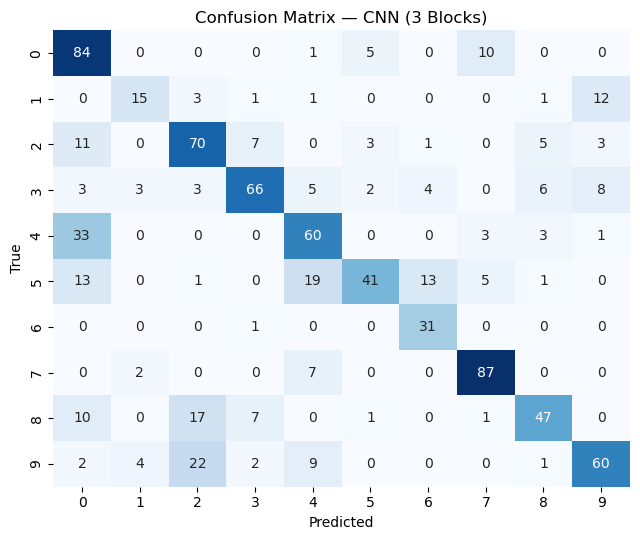

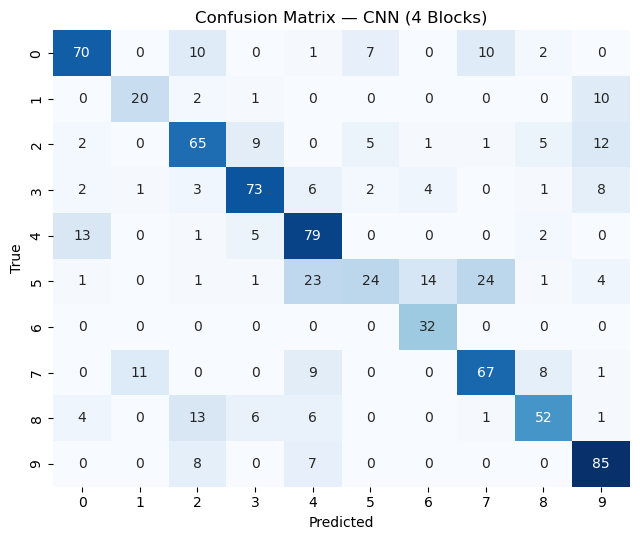

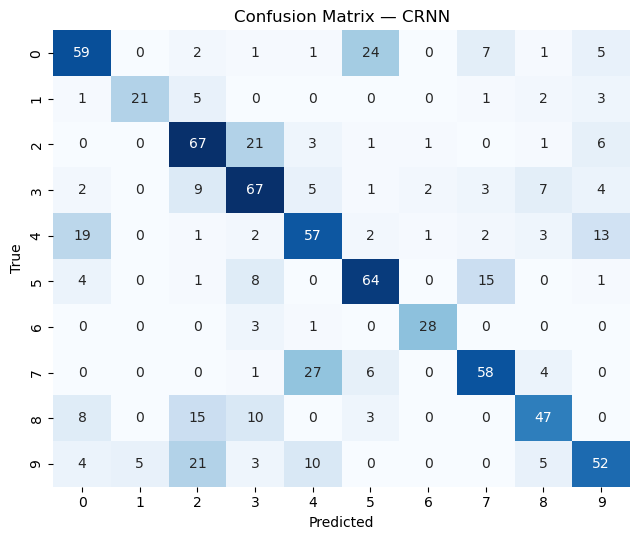

In [26]:
# Confusion Matrix
# ----------------

plot_confusion_mat(y_test, cnn3_yh, "CNN (3 Blocks)", BASE_DIR / "04e_cnn3_cf.png")
plot_confusion_mat(y_test, cnn4_yh, "CNN (4 Blocks)", BASE_DIR / "04f_cnn4_cf.png")
plot_confusion_mat(y_test, crnn_yh, "CRNN", BASE_DIR / "04g_crnn_cf.png")


### Metric Insights

| Metric    | CNN (3 Block) | CNN (4-Block) | CRNN   |
| --------- | ------------- | ------------- | ------ |
| Accuracy  | 0.6703        | **0.6774**    | 0.6213 |
| Precision | **0.6831**    | 0.6733        | 0.6569 |
| Recall    | 0.6737        | **0.6909**    | 0.6390 |
| F1-Score  | 0.6626        | **0.6673**    | 0.6448 |
| Loss      | **1.0259**    | 1.5268        | 2.1676 |

- **CNN-3** gives best **precision vs. stability trade-off**
- **CNN-4** gives marginal recall improvement but worse loss
- **CRNN** achieves slightly better per-class temporal modeling (e.g., alarms) but lower macro-metrics


### Confusion Matrix Observations

- Generally, 
- Misclassification between 2↔8↔9 is lower than the **Classical ML models**
- **CNN (3 Blocks)**: clean diagonal, moderate confusion between 0↔8 and 3↔4
- **CNN (4 Blocks)**: sharper diagonal but occasional drift (e.g., 5 misclassified as 4/6/7), lowest confusion between 2↔8↔9
- **CRNN**: broader misclassification spread — particularly 0→5, 2→3, and 7→4, reflecting noise sensitivity


## Conclusions

- **Best Generalizing Model** → **CNN (3 Blocks)**
    - Balanced precision, recall and lowest loss
    - Simplest yet effective baseline
- **Marginal Gain from Depth** → CNN (4 Blocks)
    - Shows slightly higher accuracy but overfits more
- **CRNN Not Optimal** → Needs more data or stronger regularization
    - Higher capacity didn’t translate to accuracy gains

**Final Note:** 

- For this dataset size and variability, **CNNs outperform CRNN** in both efficiency and reliability for the Deep Learning models
- **XGBoost** from the Classical ML modelling outperformed all Deep Learning models in macro statistics
- **Deep Learning** models showed **higher capacity** to learn from features


## Future Exploration

**1) Data Augmentation (Waveform)**

- Add realistic noise (street/office/white), random SNR (e.g., +5 to +25 dB)
- Time-stretch ±(5–10)%, pitch-shift ±(1–2) semitones (keep class semantics)
- Random gain, wet/dry, small reverb/room impulse responses, random start-crop of the 4-s window
- MixUp between clips of the **same** class (α≈0.2) to smooth decision boundaries

**2) Data Augmentation (Spectrogram)**

- **SpecAugment**: time masking, frequency masking, light time warping
- Image-style augments that preserve semantics: random erasing/ Cutout, MixUp/CutMix on spectrograms, slight jitter in intensity
- **Avoid geometric flips, rotations and scaling**  → not valid

**3) Stronger temporal heads**

- **Dilated 1D Conv / TCN** over time for long context with low cost
- **Attention pooling / learnable temporal pooling** (e.g., GMP+Att) instead of GAP
- Try **AST/PaSST-style** patch transformers on spectrogram patches for a transformer baseline (with patchout/dropout)

**4) Transfer learning**

- *Audio-pretrained backbones (recommended):*
    - **YAMNet (MobileNetV1 on AudioSet)**, **VGGish**, **PANNs (CNN14)**, **AST / PaSST**, **HTS-AT**, **BEATs**
    - Use as frozen feature extractor → small classifier head, then progressively unfreeze
- *Image-pretrained on spectrograms (works reasonably well):*
    - **ResNet-18/34**, **EfficientNet-B0/B1**, **ConvNeXt-T** (freeze early, fine-tune late)
    - Caveat: domain shift (ImageNet colors/edges ≠ spectro patterns) → need spectro-specific augments + lower LR.

**5) Multimodal (two-branch) models - waveform + spectrogram**

- **Early fusion:** project both branches to a common dim and concatenate per-time features → temporal head (TCN/GRU/Attention)
- **Late fusion:** independent predictions (wave CNN/TCN and spec CNN) + weighted/learned averaging
- **Joint fusion with attention gating:** attention over branches conditioned on noise level/SNR
- Practical start: light 1D-CNN/TCN on waveform + your 3-block CNN on spectrogram → concat → attention pooling → classifier

**6) Regularization & training tactics to try across models**

- Label smoothing (ε≈0.05), dropout tuning, weight decay (1e-4 - 5e-4)
- Cosine LR with warmup - one-cycle policy for faster convergence
- Class-balanced sampling
